# **Bar Charts**


We will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [1]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  5.09MB/s    in 43s     

2026-09-06 16:50:32 (3.52 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



In [2]:
import numpy as np

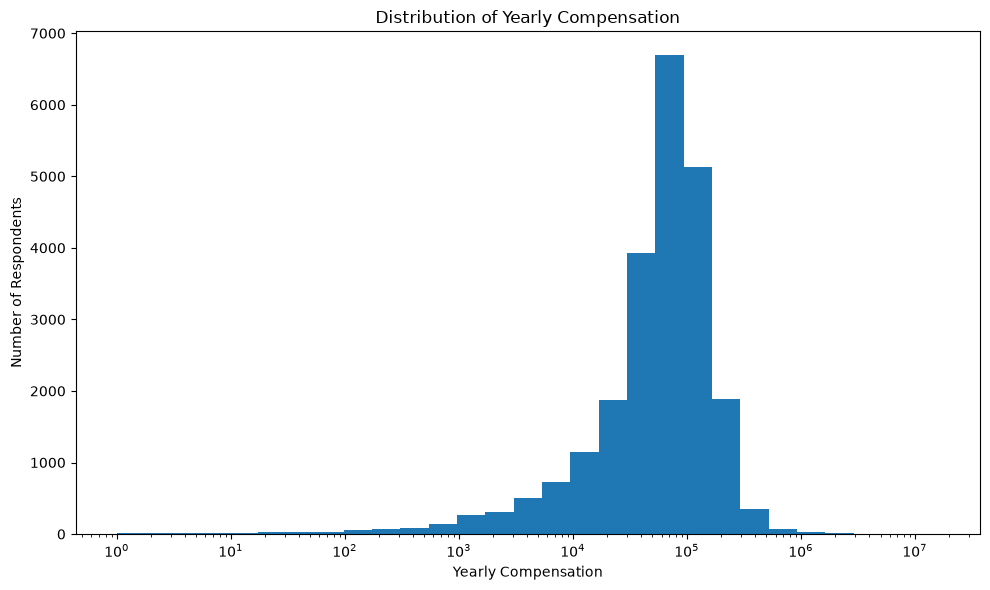

In [3]:
# Histogram of ConvertedCompYearly

comp = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce").dropna()
comp = comp[comp > 0]

bins = np.logspace(
    np.log10(comp.min()),
    np.log10(comp.max()),
    30
)

plt.figure(figsize=(10, 6))
plt.hist(comp, bins=bins)

plt.xscale("log")
plt.title("Distribution of Yearly Compensation")
plt.xlabel("Yearly Compensation")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()


##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



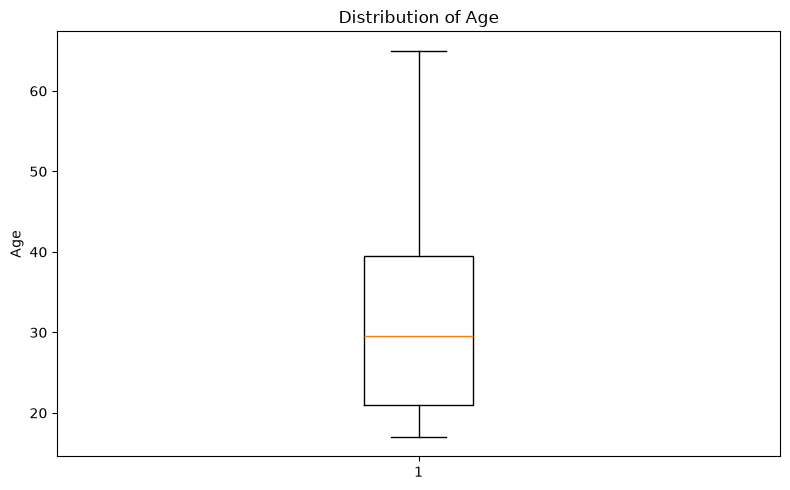

In [4]:
# Box Plot of Age

age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

age_numeric = df["Age"].map(age_map).dropna()

plt.figure(figsize=(8, 5))
plt.boxplot(age_numeric)

plt.title("Distribution of Age")
plt.ylabel("Age")

plt.tight_layout()
plt.show()


### Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



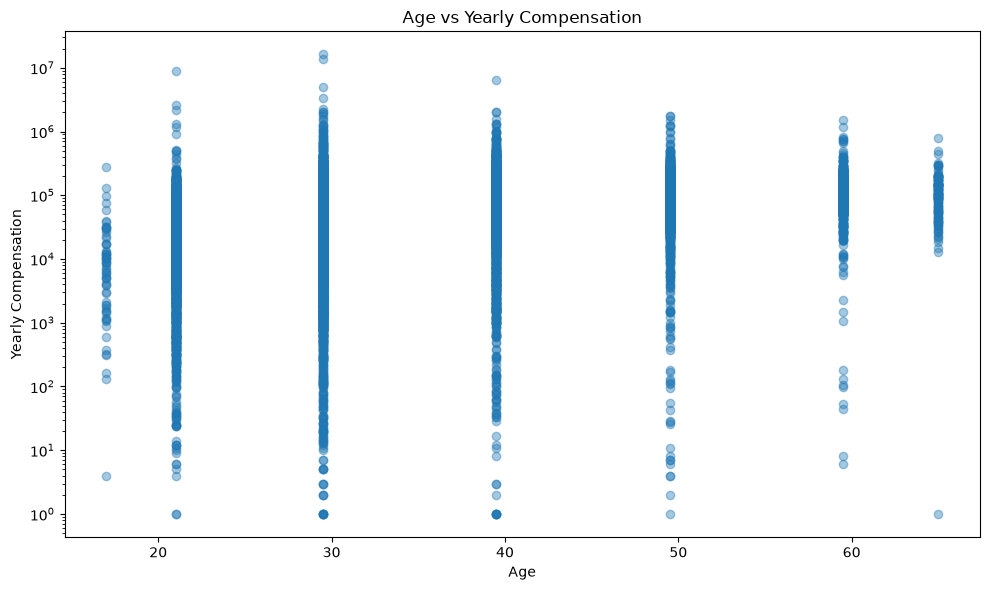

In [15]:
# Scatter Plot of Age_numeric and ConvertedCompYearly

age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

plot_df = df[["Age", "ConvertedCompYearly"]].copy()

plot_df["Age_numeric"] = plot_df["Age"].map(age_map)

plot_df["ConvertedCompYearly"] = pd.to_numeric(
    plot_df["ConvertedCompYearly"],
    errors="coerce"
)

plot_df = plot_df.dropna()

plot_df = plot_df[plot_df["ConvertedCompYearly"] > 0]

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df["Age_numeric"],
    plot_df["ConvertedCompYearly"],
    alpha=0.4
)

plt.title("Age vs Yearly Compensation")
plt.xlabel("Age")
plt.ylabel("Yearly Compensation")

plt.yscale("log")

plt.tight_layout()
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


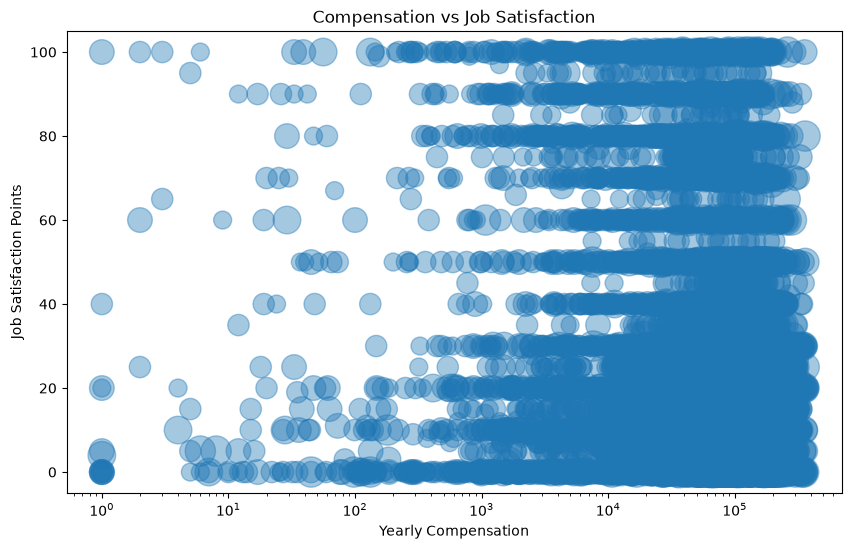

In [5]:
# Bubble Plot: Compensation vs Job Satisfaction

age_map = {
    "Under 18 years old": 17, "18-24 years old": 21,
    "25-34 years old": 29.5, "35-44 years old": 39.5,
    "45-54 years old": 49.5, "55-64 years old": 59.5,
    "65 years or older": 65
}

plot_df = df[["Age", "ConvertedCompYearly", "JobSatPoints_6"]].copy()

plot_df["Age"] = plot_df["Age"].map(age_map)
plot_df["ConvertedCompYearly"] = pd.to_numeric(plot_df["ConvertedCompYearly"], errors="coerce")
plot_df["JobSatPoints_6"] = pd.to_numeric(plot_df["JobSatPoints_6"], errors="coerce")

plot_df = plot_df.dropna()
plot_df = plot_df[plot_df["ConvertedCompYearly"] > 0]

# Remove extreme values
plot_df = plot_df[
    plot_df["ConvertedCompYearly"] <= plot_df["ConvertedCompYearly"].quantile(0.99)
]

plt.figure(figsize=(10, 6))
plt.scatter(
    plot_df["ConvertedCompYearly"],
    plot_df["JobSatPoints_6"],
    s=plot_df["Age"] * 8,
    alpha=0.4
)

plt.xscale("log")
plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction Points")
plt.title("Compensation vs Job Satisfaction")
plt.show()

### Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



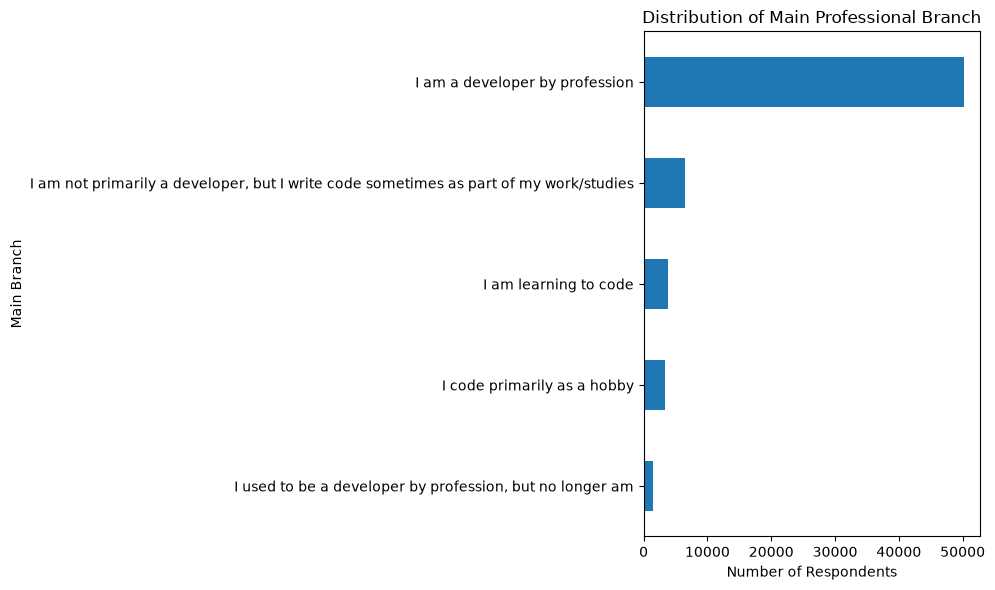

In [18]:
# Horizontal Bar Chart of MainBranch Distribution

counts = df["MainBranch"].dropna().value_counts()

plt.figure(figsize=(10, 6))

counts.sort_values().plot(kind="barh")

plt.title("Distribution of Main Professional Branch")
plt.xlabel("Number of Respondents")
plt.ylabel("Main Branch")

plt.tight_layout()
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



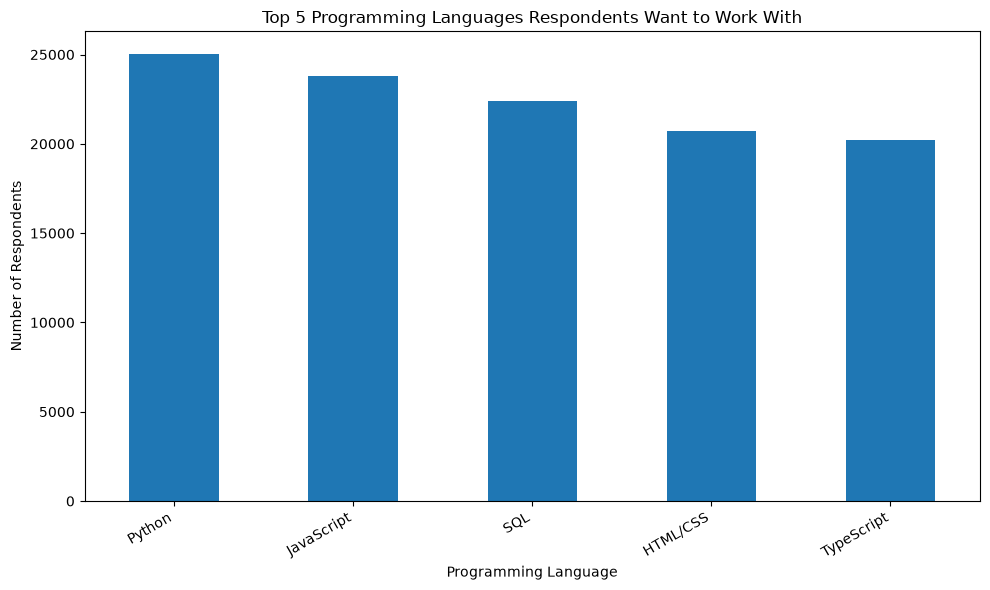

In [19]:
# Vertical Bar Chart of Top 5 Programming Languages

languages = (
    df["LanguageWantToWorkWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
    .head(5)
)

plt.figure(figsize=(10, 6))

languages.plot(kind="bar")

plt.title("Top 5 Programming Languages Respondents Want to Work With")
plt.xlabel("Programming Language")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


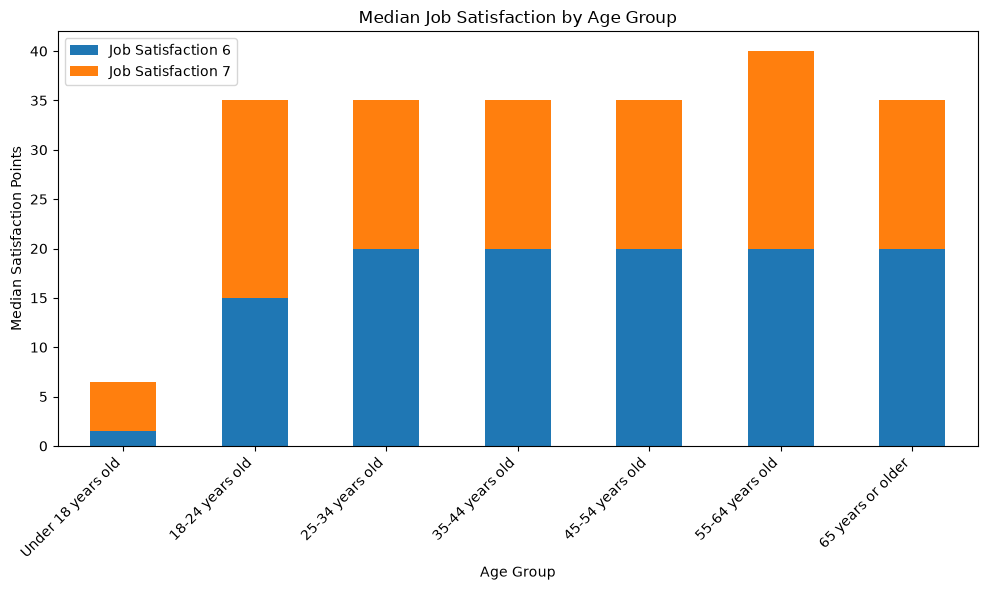

In [20]:
# Stacked Bar Chart of Median Job Satisfaction by Age Group

age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

plot_df = df[["Age", "JobSatPoints_6", "JobSatPoints_7"]].copy()

plot_df["JobSatPoints_6"] = pd.to_numeric(
    plot_df["JobSatPoints_6"], errors="coerce"
)

plot_df["JobSatPoints_7"] = pd.to_numeric(
    plot_df["JobSatPoints_7"], errors="coerce"
)

table = plot_df.groupby("Age")[[
    "JobSatPoints_6",
    "JobSatPoints_7"
]].median()

table = table.reindex(age_order).dropna(how="all")

table.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Median Job Satisfaction by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Satisfaction Points")
plt.xticks(rotation=45, ha="right")
plt.legend(["Job Satisfaction 6", "Job Satisfaction 7"])

plt.tight_layout()
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



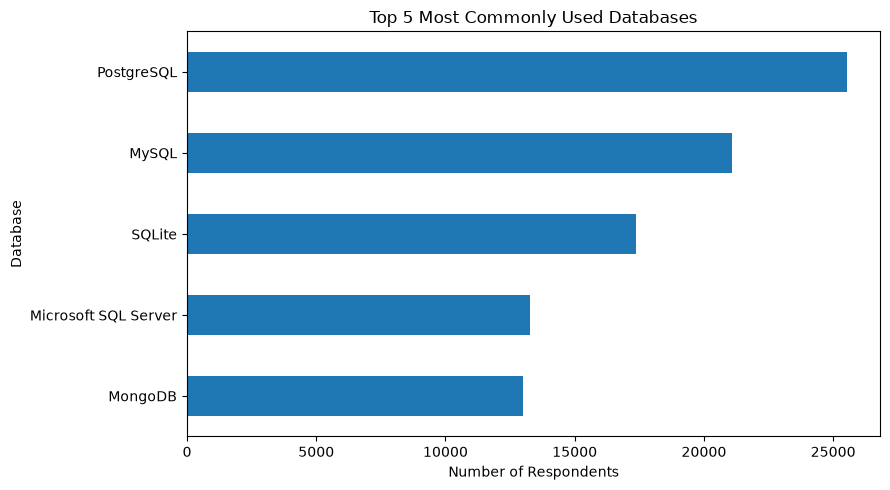

In [21]:
# Bar Chart of Database Popularity

databases = (
    df["DatabaseHaveWorkedWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
    .head(5)
)

plt.figure(figsize=(9, 5))

databases.sort_values().plot(kind="barh")

plt.title("Top 5 Most Commonly Used Databases")
plt.xlabel("Number of Respondents")
plt.ylabel("Database")

plt.tight_layout()
plt.show()

### Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



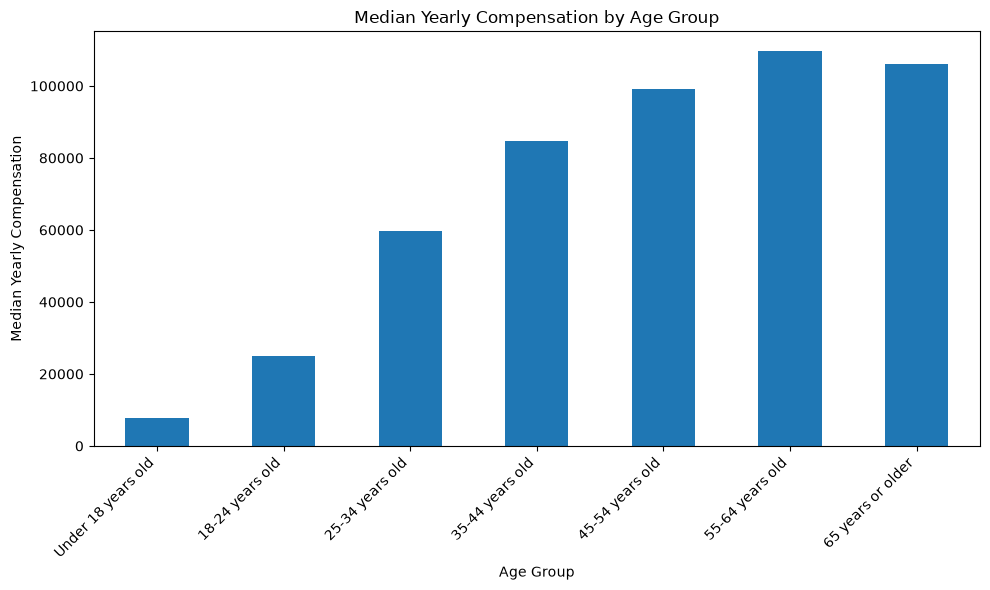

In [22]:
# Grouped Bar Chart of Median ConvertedCompYearly by Age Group

age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

plot_df = df[["Age", "ConvertedCompYearly"]].copy()

plot_df["ConvertedCompYearly"] = pd.to_numeric(
    plot_df["ConvertedCompYearly"],
    errors="coerce"
)

table = (
    plot_df.groupby("Age")["ConvertedCompYearly"]
    .median()
    .reindex(age_order)
    .dropna()
)

plt.figure(figsize=(10, 6))

table.plot(kind="bar")

plt.title("Median Yearly Compensation by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Yearly Compensation")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



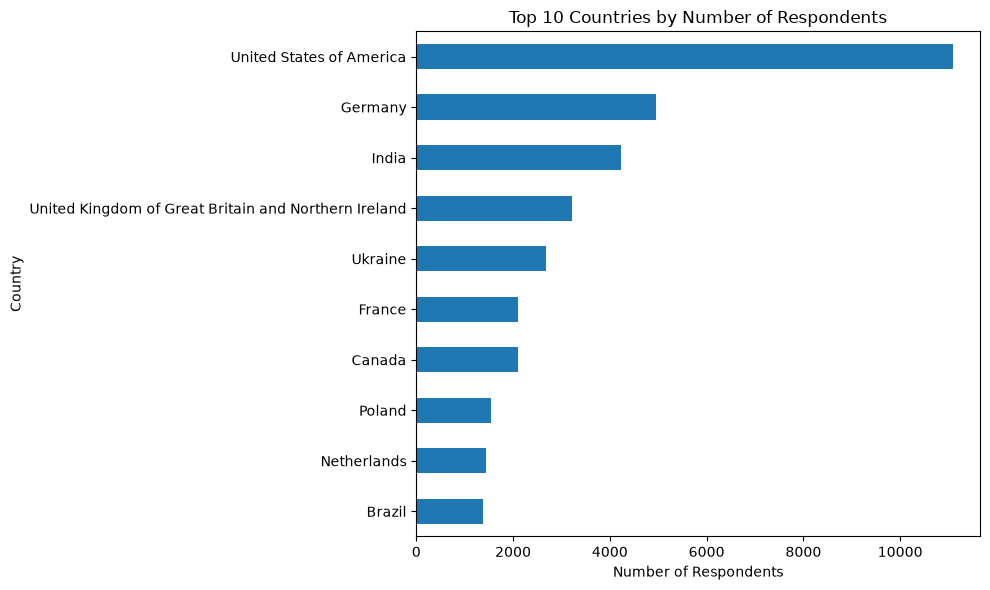

In [23]:
# Bar Chart of Respondent Count by Country

countries = df["Country"].dropna().value_counts().head(10)

plt.figure(figsize=(10, 6))

countries.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Number of Respondents")
plt.xlabel("Number of Respondents")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

## Summary


- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.
